In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("heart.csv")
print(df.head)

<bound method NDFrame.head of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2  

# Deletion of duplicate data

In [7]:
duplicates = df.duplicated()
print("\nTotal duplicate rows:", duplicates.sum())


Total duplicate rows: 723


In [8]:
df_cleaned = df.drop_duplicates()

In [9]:
print(df_cleaned.head)

<bound method NDFrame.head of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     52    1   0       125   212    0        1      168      0      1.0   
1     53    1   0       140   203    1        0      155      1      3.1   
2     70    1   0       145   174    0        1      125      1      2.6   
3     61    1   0       148   203    0        1      161      0      0.0   
4     62    0   0       138   294    1        1      106      0      1.9   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
723   68    0   2       120   211    0        0      115      0      1.5   
733   44    0   2       108   141    0        1      175      0      0.6   
739   52    1   0       128   255    0        1      161      1      0.0   
843   59    1   3       160   273    0        0      125      0      0.0   
878   54    1   0       120   188    0        1      113      0      1.4   

     slope  ca  thal  target  
0        2   2     3      

# Converting to Numpy array

In [11]:
X = df_cleaned.iloc[:, :-1].values
y = df_cleaned.iloc[:, -1].values

# Missing Data

In [14]:
print(df_cleaned.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [13]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X[:, :-1] = imputer.fit_transform(X[:, :-1])

# Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X[:, :-1] = sc.fit_transform(X[:, :-1])

In [17]:
print(X[:10])

[[-0.26796589  0.68265615 -0.93520799 -0.37655636 -0.66772815 -0.41844626
   0.90165655  0.80603539 -0.69834428 -0.03712404  0.97951442  1.27497996
   3.        ]
 [-0.15726042  0.68265615 -0.93520799  0.47891019 -0.84191811  2.38979311
  -1.0025412   0.23749516  1.43195847  1.77395808 -2.27118179 -0.71491124
   3.        ]
 [ 1.72473259  0.68265615 -0.93520799  0.76406571 -1.40319685 -0.41844626
   0.90165655 -1.07452077  1.43195847  1.34274805 -2.27118179 -0.71491124
   3.        ]
 [ 0.72838335  0.68265615 -0.93520799  0.93515902 -0.84191811 -0.41844626
   0.90165655  0.49989834 -0.69834428 -0.8995441   0.97951442  0.28003436
   3.        ]
 [ 0.83908882 -1.46486632 -0.93520799  0.36484799  0.91933586  2.38979311
   0.90165655 -1.90546419 -0.69834428  0.73905401 -0.64583368  2.26992556
   2.        ]
 [ 0.39626693 -1.46486632 -0.93520799 -1.80233394  0.02903166 -0.41844626
  -1.0025412  -1.20572236 -0.69834428 -0.03712404 -0.64583368 -0.71491124
   2.        ]
 [ 0.39626693  0.68265

In [20]:
print(df_cleaned.head)

<bound method NDFrame.head of      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     52    1   0       125   212    0        1      168      0      1.0   
1     53    1   0       140   203    1        0      155      1      3.1   
2     70    1   0       145   174    0        1      125      1      2.6   
3     61    1   0       148   203    0        1      161      0      0.0   
4     62    0   0       138   294    1        1      106      0      1.9   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
723   68    0   2       120   211    0        0      115      0      1.5   
733   44    0   2       108   141    0        1      175      0      0.6   
739   52    1   0       128   255    0        1      161      1      0.0   
843   59    1   3       160   273    0        0      125      0      0.0   
878   54    1   0       120   188    0        1      113      0      1.4   

     slope  ca  thal  target  
0        2   2     3      

# Pearson Correlation

In [22]:
correlation = df_cleaned['age'].corr(df_cleaned['thalach'])
print("Correlation between age and chol:", correlation)

Correlation between age and chol: -0.39523518755348025


# Chi-Square


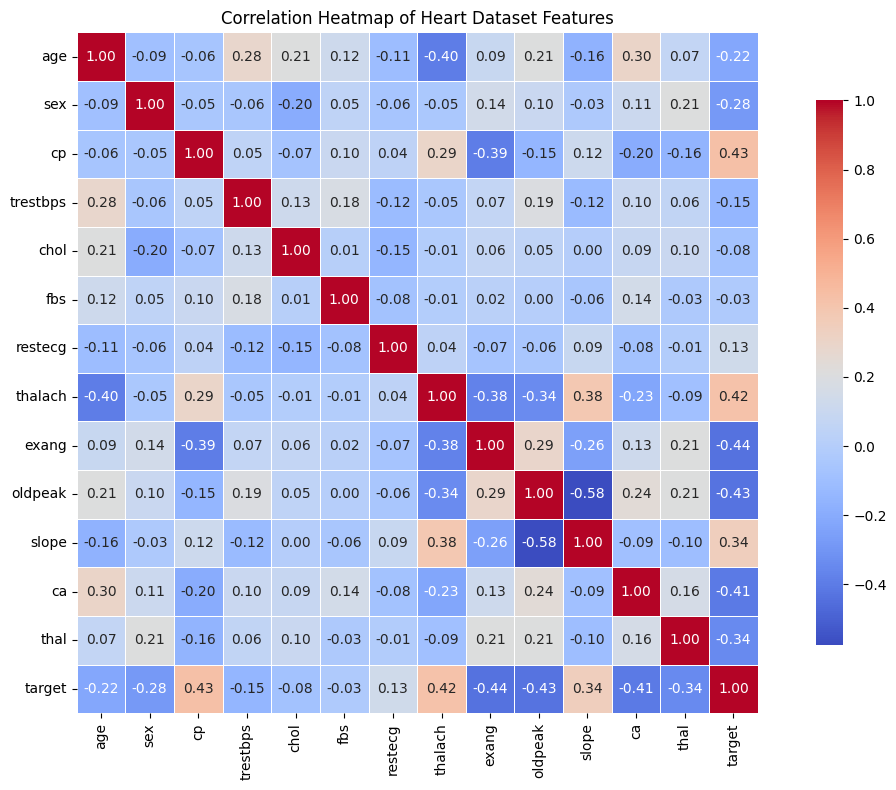

In [24]:
import seaborn as sns

corr_matrix = df_cleaned.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(corr_matrix,
            annot=True,        # show correlation values
            fmt=".2f",         # format float to 2 decimal places
            cmap='coolwarm',   # color map
            square=True,       # square cells
            linewidths=0.5,    # space between cells
            cbar_kws={"shrink": .8})  # color bar size

plt.title("Correlation Heatmap of Heart Dataset Features")
plt.tight_layout()
plt.show()